# Import Libraries and Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import norm
from scipy import stats

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn import model_selection
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score, fbeta_score
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn import metrics

In [ ]:
car_dataset = pd.read_csv('used_car_price_dataset_extended.csv')

car_dataset : Original Data

car_dataset_2 : Filled N/A Data

car_dataset_3 : Label Encoding

# Data Overview

In [ ]:
car_dataset.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


## Checking Data Type

All data types are appropriate

In [ ]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


# Data Cleaning

## Filling N/A Value

In [ ]:
car_dataset['service_history'].unique()

array([nan, 'Full', 'Partial'], dtype=object)

In [ ]:
car_dataset_2 = car_dataset.copy()

In [ ]:
car_dataset_2['service_history'] = car_dataset_2['service_history'].fillna('No Service')

In [ ]:
car_dataset_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     10000 non-null  object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


## Checking Duplicated Data

In [ ]:
car_dataset_2.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

## Histogram of Numerical Feature

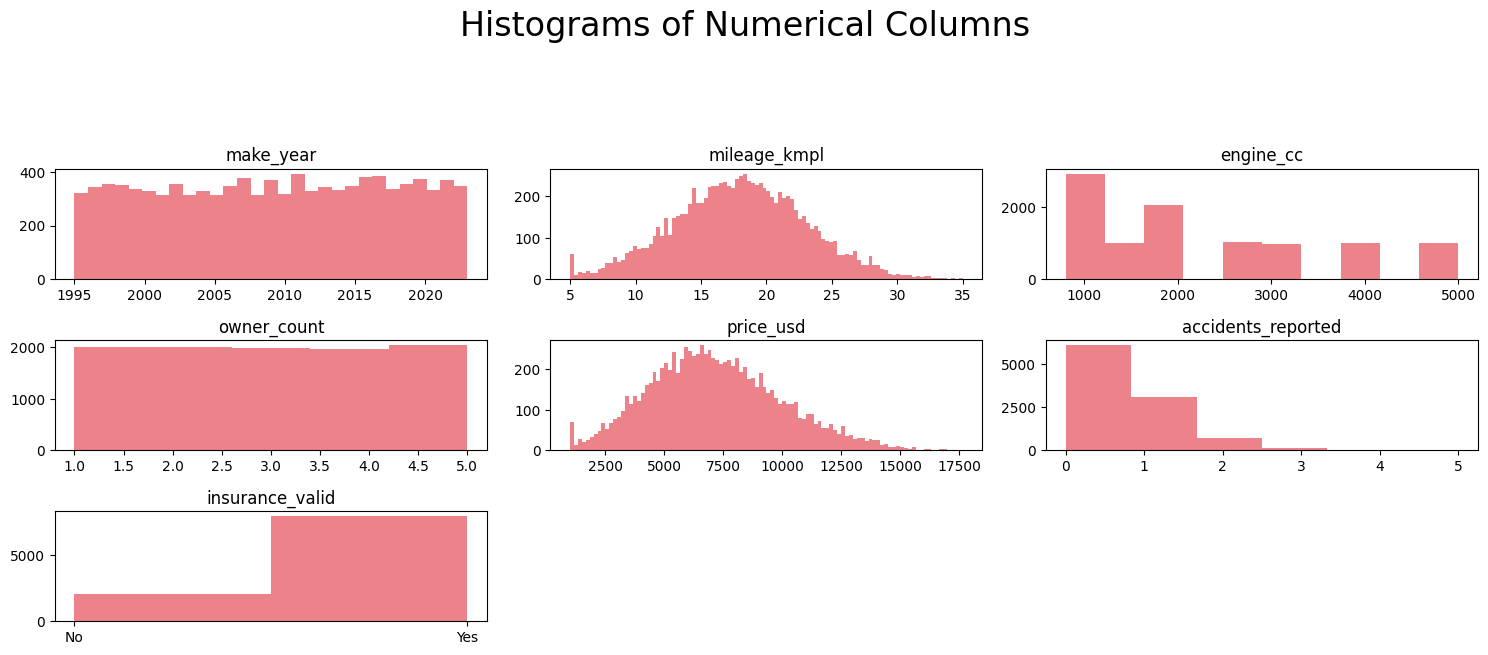

In [ ]:
numerical_feature = car_dataset_2[['make_year','mileage_kmpl','engine_cc','owner_count','price_usd','accidents_reported','insurance_valid']]


fig = plt.figure(figsize=(15, 12))
plt.suptitle('Histograms of Numerical Columns\n',horizontalalignment="center",fontstyle = "normal", fontsize = 24, fontfamily = "sans-serif")
for i in range(numerical_feature.shape[1]):
    plt.subplot(6, 3, i + 1)
    f = plt.gca()
    f.set_title(numerical_feature.columns.values[i])

    vals = np.size(numerical_feature.iloc[:, i].unique())
    if vals >= 100:
        vals = 100

    plt.hist(numerical_feature.iloc[:, i], bins=vals, color = '#ec838a')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## Car's Brand vs Price

Car's brand doesn't have a significant influence to the car's price

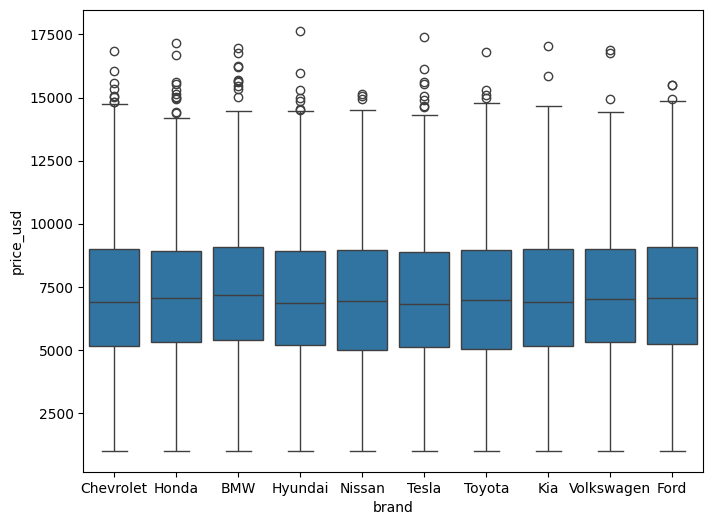

In [ ]:
data = pd.concat([car_dataset_2['price_usd'], car_dataset_2['brand']], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x='brand', y="price_usd", data=data)

## Engine Capacity vs Price

There is positive correlation between engine_cc and price_usd

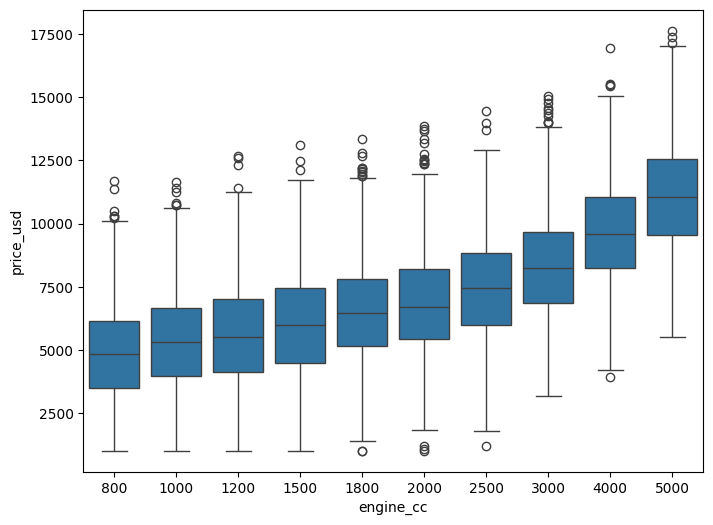

In [ ]:
data = pd.concat([car_dataset_2['price_usd'], car_dataset_2['engine_cc']], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x='engine_cc', y="price_usd", data=data)

## Cars Population by its Fuel Type

Petrol fuel type dominates by almost half of the used cars population, followed by Diesel fuel type with 40.6%, and Electric cars shared only 9.7%

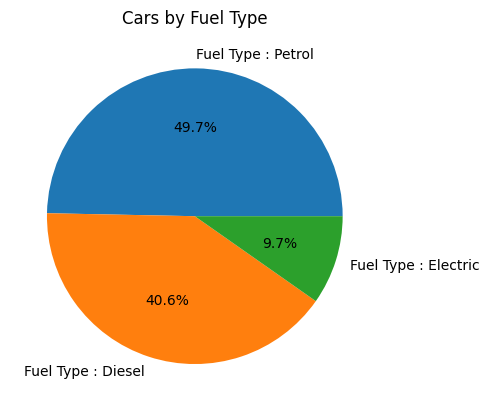

In [ ]:
fuel_type = car_dataset_2['fuel_type']

fuel_type_counts = fuel_type.value_counts()

#define bar label
pie_labels = [f"Fuel Type : {fuel}" for fuel in fuel_type_counts.index]

#create pie chart
plt.pie(fuel_type_counts.values,labels = pie_labels, autopct = "%1.1f%%")

#add title and axis labels
plt.title("Cars by Fuel Type")
plt.show()

plt.show()

## Cars Population by its Transmission Type

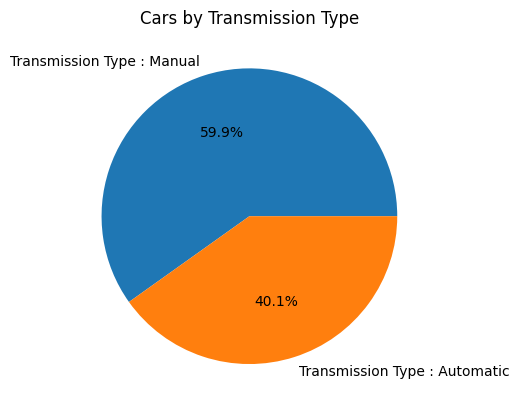

In [ ]:
transmission_type = car_dataset_2['transmission']

transmission_type_counts = transmission_type.value_counts()

#define bar label
pie_labels = [f"Transmission Type : {transmission}" for transmission in transmission_type_counts.index]

#create pie chart
plt.pie(transmission_type_counts.values,labels = pie_labels, autopct = "%1.1f%%")

#add title and axis labels
plt.title("Cars by Transmission Type")
plt.show()

plt.show()

## Coefficient of Correlation Heatmap

Coefficient of Correlation to price_usd

Strong Positive Correlation :
engine_cc (0.68)

Moderate Positive Correlation :
make_year (0.43)

Weak Positive Correlation :
mileage_kmpl (0.21)

Weak Negative Correlation :
owner_count (-0.26)
accidents_reported (-0.0015)



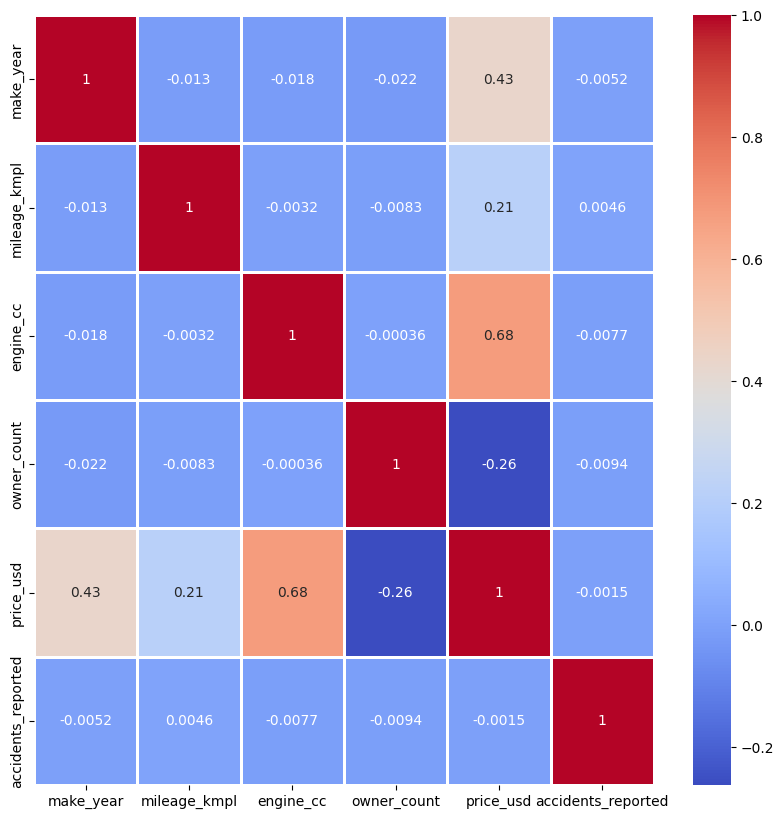

In [ ]:
plt.figure(figsize=(10,10))
ax = sns.heatmap(car_dataset_2.select_dtypes(exclude= 'object').corr(), cmap = "coolwarm", annot=True, linewidth=2)

# Data Pre-Processing

## Label Encoding

### Binary Label Encoding

In [ ]:
car_dataset_3 = car_dataset_2.copy()

In [ ]:
encoders = {}

label_encoders_count = 0
for col in car_dataset_3.columns[:]:
    if car_dataset_3[col].dtype == 'object':
        if len(list(car_dataset_3[col].unique())) <= 2:
            print(col)
            label_encoders = LabelEncoder()
            label_encoders.fit(car_dataset_3[col])
            car_dataset_3[col] = label_encoders.transform(car_dataset_3[col])
            encoders[col] = label_encoders
            label_encoders_count += 1
print('{} columns were label encoded.'.format(label_encoders_count))

transmission
insurance_valid
2 columns were label encoded.


In [ ]:
car_dataset_3

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,1,White,No Service,0,0
1,2014,17.59,1500,Petrol,4,5943.50,Honda,1,Black,No Service,0,1
2,2023,18.09,2500,Diesel,5,9273.58,BMW,0,Black,Full,1,1
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,1,Blue,Full,0,1
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,0,Red,Full,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1996,15.25,1500,Petrol,2,5498.71,Hyundai,1,Silver,No Service,0,1
9996,1997,14.45,5000,Diesel,1,9588.31,Honda,1,Gray,Full,0,1
9997,2002,19.41,1000,Diesel,4,4557.10,Kia,1,Black,Full,0,1
9998,2005,12.95,4000,Petrol,5,7413.59,BMW,0,Blue,Full,0,1


### One Hot Encoding

In [ ]:
car_dataset_3 = pd.get_dummies(car_dataset_3)

In [ ]:
car_dataset_3

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,transmission,accidents_reported,insurance_valid,fuel_type_Diesel,fuel_type_Electric,...,brand_Volkswagen,color_Black,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Full,service_history_No Service,service_history_Partial
0,2001,8.17,4000,4,8587.64,1,0,0,False,False,...,False,False,False,False,False,False,True,False,True,False
1,2014,17.59,1500,4,5943.50,1,0,1,False,False,...,False,True,False,False,False,False,False,False,True,False
2,2023,18.09,2500,5,9273.58,0,1,1,True,False,...,False,True,False,False,False,False,False,True,False,False
3,2009,11.28,800,1,6836.24,1,0,1,False,False,...,False,False,True,False,False,False,False,True,False,False
4,2005,12.23,1000,2,4625.79,0,0,1,False,False,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1996,15.25,1500,2,5498.71,1,0,1,False,False,...,False,False,False,False,False,True,False,False,True,False
9996,1997,14.45,5000,1,9588.31,1,0,1,True,False,...,False,False,False,True,False,False,False,True,False,False
9997,2002,19.41,1000,4,4557.10,1,0,1,True,False,...,False,True,False,False,False,False,False,True,False,False
9998,2005,12.95,4000,5,7413.59,0,0,1,False,False,...,False,False,True,False,False,False,False,True,False,False


## Split Dataset into Feature and Target

In [ ]:
target_dataset = car_dataset_3["price_usd"]
feature_dataset = car_dataset_3.drop(columns="price_usd")

## Split Dataset into Train and Test

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(feature_dataset, target_dataset,
                                                    test_size = 0.2,
                                                    random_state = 0)

In [ ]:
x_train

,make_year,mileage_kmpl,engine_cc,owner_count,transmission,accidents_reported,insurance_valid,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,...,brand_Volkswagen,color_Black,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Full,service_history_No Service,service_history_Partial
7389,2018,7.35,1000,2,0,0,1,False,False,True,...,False,True,False,False,False,False,False,True,False,False
9275,2015,25.12,5000,3,1,2,1,False,False,True,...,True,False,False,False,False,True,False,False,False,True
2995,1998,15.02,1000,4,1,0,1,False,False,True,...,False,True,False,False,False,False,False,True,False,False
5316,2021,24.43,1500,4,1,0,1,True,False,False,...,False,False,False,False,False,True,False,True,False,False
356,2014,20.17,1000,2,1,0,1,False,False,True,...,True,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9225,2018,23.28,2000,5,0,1,1,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4859,2004,15.83,1200,1,1,0,1,False,False,True,...,False,False,True,False,False,False,False,True,False,False
3264,2011,14.95,1000,4,1,0,1,False,False,True,...,False,False,True,False,False,False,False,False,False,True
9845,2004,20.00,1000,2,1,0,1,False,True,False,...,False,False,True,False,False,False,False,True,False,False


## Feature Scaling

In [ ]:
scaler_x = StandardScaler()
x_train2 = pd.DataFrame(scaler_x.fit_transform(x_train))
x_train2.columns = x_train.columns.values
x_train2.index = x_train.index.values
x_train = x_train2

x_test2 = pd.DataFrame(scaler_x.transform(x_test))
x_test2.columns = x_test.columns.values
x_test2.index = x_test.index.values
x_test = x_test2

In [ ]:
x_train

,make_year,mileage_kmpl,engine_cc,owner_count,transmission,accidents_reported,insurance_valid,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,...,brand_Volkswagen,color_Black,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Full,service_history_No Service,service_history_Partial
7389,1.056225,-2.100207,-0.996029,-0.712860,-1.223789,-0.711902,0.507996,-0.826956,-0.328451,1.007025,...,-0.345698,2.183539,-0.440893,-0.449359,-0.446744,-0.441499,-0.446744,0.99925,-0.505658,-0.648425
9275,0.698602,1.427309,2.109434,-0.008105,0.817135,2.186426,0.507996,-0.826956,-0.328451,1.007025,...,2.892695,-0.457972,-0.440893,-0.449359,-0.446744,2.265010,-0.446744,-1.00075,-0.505658,1.542199
2995,-1.327929,-0.577638,-0.996029,0.696651,0.817135,-0.711902,0.507996,-0.826956,-0.328451,1.007025,...,-0.345698,2.183539,-0.440893,-0.449359,-0.446744,-0.441499,-0.446744,0.99925,-0.505658,-0.648425
5316,1.413848,1.290338,-0.607846,0.696651,0.817135,-0.711902,0.507996,1.209254,-0.328451,-0.993024,...,-0.345698,-0.457972,-0.440893,-0.449359,-0.446744,2.265010,-0.446744,0.99925,-0.505658,-0.648425
356,0.579394,0.444687,-0.996029,-0.712860,0.817135,-0.711902,0.507996,-0.826956,-0.328451,1.007025,...,2.892695,-0.457972,2.268125,-0.449359,-0.446744,-0.441499,-0.446744,-1.00075,-0.505658,1.542199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9225,1.056225,1.062052,-0.219663,1.401406,-1.223789,0.737262,0.507996,-0.826956,-0.328451,1.007025,...,-0.345698,-0.457972,-0.440893,-0.449359,2.238419,-0.441499,-0.446744,-1.00075,-0.505658,1.542199
4859,-0.612683,-0.416845,-0.840755,-1.417616,0.817135,-0.711902,0.507996,-0.826956,-0.328451,1.007025,...,-0.345698,-0.457972,2.268125,-0.449359,-0.446744,-0.441499,-0.446744,0.99925,-0.505658,-0.648425
3264,0.221771,-0.591534,-0.996029,0.696651,0.817135,-0.711902,0.507996,-0.826956,-0.328451,1.007025,...,-0.345698,-0.457972,2.268125,-0.449359,-0.446744,-0.441499,-0.446744,-1.00075,-0.505658,1.542199
9845,-0.612683,0.410940,-0.996029,-0.712860,0.817135,-0.711902,0.507996,-0.826956,3.044598,-0.993024,...,-0.345698,-0.457972,2.268125,-0.449359,-0.446744,-0.441499,-0.446744,0.99925,-0.505658,-0.648425


# Model Selection

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score

def test_model(model, X_train=x_train, y_train=y_train):
    cv = KFold(n_splits = 10, shuffle=True, random_state = 45)
    r2 = make_scorer(r2_score)

    r2_val_score = cross_val_score(model, x_train, y_train, cv=cv, scoring = r2)
    score = [r2_val_score.mean()]
    return score

## Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=0)
print(f"Decision Tree Regressor R² score: {test_model(dt_reg)[0]:.4f}")

Decision Tree Regressor R² score: 0.7008


## Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=0)
print(f"Random Forest Regressor R² score: {test_model(rf_reg)[0]:.4f}")

Random Forest Regressor R² score: 0.8472


## Linear Regression

In [ ]:
import sklearn.linear_model as linear_model
model_lr = linear_model.LinearRegression()
print(f"Linear Regression R² score: {test_model(model_lr)[0]:.5f}")

Linear Regression R² score: 0.87006


## XG Boost Regressor

In [ ]:
!pip install --upgrade xgboost

import xgboost

xgb_reg = xgboost.XGBRegressor()
print(f"XG Boost Regressor R² score: {test_model(xgb_reg)[0]:.4f}")

XG Boost Regressor R² score: 0.8413


## Support Vector Regressor

In [ ]:
from sklearn.svm import SVR

# Support Vector Regressor
# SVR can be computationally intensive on large datasets.
# For demonstration, we'll use a linear kernel, but other kernels (e.g., 'rbf') are common.

# It's important to scale the data for SVR, which has already been done in the preprocessing steps.
svr_reg = SVR(kernel='linear')
print(f"Support Vector Regressor R² score: {test_model(svr_reg)[0]:.4f}")

Support Vector Regressor R² score: 0.8481


## Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

# Lasso Regressor

lasso_reg = Lasso(alpha = 0.2)
print(f"Lasso Regressor R² score: {test_model(lasso_reg)[0]:.4f}")

Lasso Regressor R² score: 0.8701


## Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

# Ridge Regressor
ridge_reg = Ridge(alpha = 0.2)
print(f"Ridge Regressor R² score: {test_model(ridge_reg)[0]:.4f}")

Ridge Regressor R² score: 0.8701


## ElasticNet Regression

In [ ]:
from sklearn.linear_model import ElasticNet

# ElasticNet Regressor
elastic_net_reg = ElasticNet(random_state=0)
print(f"ElasticNet Regressor R² score: {test_model(elastic_net_reg)[0]:.4f}")

ElasticNet Regressor R² score: 0.7717


## Polynomial Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Polynomial Regression
# We'll create a pipeline to first transform features and then apply linear regression.
# Let's try with degree 2 for polynomial features.

poly_reg_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())

print(f"Polynomial Regression R² score: {test_model(poly_reg_model)[0]:.4f}")

Polynomial Regression R² score: 0.8649


# Ridge Regression Training & Testing

## Hyperparameter Tuning (alpha)

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score

def test_model(model, X_train, y_train):
    cv = KFold(n_splits = 10, shuffle=True, random_state = 45)
    r2 = make_scorer(r2_score)

    r2_val_score = cross_val_score(model, X_train, y_train, cv=cv, scoring = r2)
    score = [r2_val_score.mean()]
    return score

def find_optimal_ridge_alpha(alphas, X_train, y_train, test_model_func):
    best_alpha = None
    best_r2_score = -np.inf

    for alpha in alphas:
        ridge_model = Ridge(alpha=alpha, random_state=0)
        r2_score_mean = test_model_func(ridge_model, X_train, y_train)[0]

        if r2_score_mean > best_r2_score:
            best_r2_score = r2_score_mean
            best_alpha = alpha

    return best_alpha, best_r2_score

# Example usage:
alphas_to_test = np.logspace(-3, 3, 100) # Test alphas from 0.001 to 1000

optimal_alpha, max_r2 = find_optimal_ridge_alpha(alphas_to_test, x_train, y_train, test_model)

print(f"Optimal Alpha for Ridge Regression: {optimal_alpha:.4f}")
print(f"Max R² score with optimal Alpha: {max_r2:.4f}")

Optimal Alpha for Ridge Regression: 2.8480
Max R² score with optimal Alpha: 0.8701


## Model Evaluation

In [ ]:
model_ridge = linear_model.Ridge(alpha=2.8480, random_state=0)
model_ridge.fit(x_train, y_train)

Ridge(alpha=2.848, random_state=0)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred_train = model_ridge.predict(x_train)


r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

print(f"Train R²: {r2_train:.4f}")
print(f"Train MSE: {mse_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train MAE: {mae_train:.4f}")

Train R²: 0.8711
Train MSE: 996718.4653
Train RMSE: 998.3579
Train MAE: 794.4343


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred_test = model_ridge.predict(x_test)

r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Test R²: {r2_test:.4f}")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")

Test R²: 0.8757
Test MSE: 1008852.4408
Test RMSE: 1004.4165
Test MAE: 801.5720


# Lasso Regression Training & Testing

## Hyperparameter Tuning (alpha)

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.linear_model import Lasso

def test_model(model, X_train, y_train):
    cv = KFold(n_splits = 10, shuffle=True, random_state = 45)
    r2 = make_scorer(r2_score)

    r2_val_score = cross_val_score(model, X_train, y_train, cv=cv, scoring = r2)
    score = [r2_val_score.mean()]
    return score

def find_optimal_lasso_alpha(alphas, X_train, y_train, test_model_func):
    best_alpha = None
    best_r2_score = -np.inf

    for alpha in alphas:
        # Increased max_iter further to help with convergence
        lasso_model = Lasso(alpha=alpha, random_state=0, max_iter=1000, tol=1e-4)
        r2_score_mean = test_model_func(lasso_model, X_train, y_train)[0]

        if r2_score_mean > best_r2_score:
            best_r2_score = r2_score_mean
            best_alpha = alpha

    return best_alpha, best_r2_score

# Example usage:
alphas_to_test = np.logspace(-2, 2, 100) # Test alphas from 0.01 to 100

optimal_alpha, max_r2 = find_optimal_lasso_alpha(alphas_to_test, x_train, y_train, test_model)

print(f"Optimal Alpha for Lasso Regression: {optimal_alpha:.4f}")
print(f"Max R² score with optimal Alpha: {max_r2:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.883e+08, tolerance: 5.624e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.786e+08, tolerance: 5.535e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.862e+08, tolerance: 5.573e

Optimal Alpha for Lasso Regression: 11.7681
Max R² score with optimal Alpha: 0.8702


## Model Evaluation

In [ ]:
model_lasso = linear_model.Lasso(alpha=11.7681, random_state=0)
model_lasso.fit(x_train, y_train)

Lasso(alpha=11.7681, random_state=0)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred_train = model_lasso.predict(x_train)


r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

print(f"Train R²: {r2_train:.4f}")
print(f"Train MSE: {mse_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train MAE: {mae_train:.4f}")

Train R²: 0.8709
Train MSE: 998995.4718
Train RMSE: 999.4976
Train MAE: 795.3277


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred_test = model_lasso.predict(x_test)

r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Test R²: {r2_test:.4f}")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")

Test R²: 0.8761
Test MSE: 1005735.3304
Test RMSE: 1002.8636
Test MAE: 800.5472


# KFold Model Evaluation

In [ ]:
target_dataset = car_dataset_3["price_usd"]
feature_dataset = car_dataset_3.drop(columns="price_usd")

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

x_train, x_test, y_train, y_test = train_test_split = train_test_split(
    feature_dataset, target_dataset, test_size=0.2, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lin = LinearRegression()
lasso = Lasso(alpha=11.7681)
ridge = Ridge(alpha=2.8480)

def evaluate(model, name):
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_rmse = root_mean_squared_error(y_train, train_pred)
    test_rmse = root_mean_squared_error(y_test, test_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)


    cv_scores = cross_val_score(model, feature_dataset, target_dataset , cv=kf, scoring='neg_mean_squared_error')
    cv_mse = -np.mean(cv_scores)

    print(name)
    print("  Train R2   :", train_r2)
    print("  Test R2    :", test_r2)
    print("  Train MSE :", train_mse)
    print("  Test MSE  :", test_mse)
    print("  Train RMSE :", train_rmse)
    print("  Test RMSE  :", test_rmse)
    print("  Train MAE   :", train_mae)
    print("  Test MAE    :", test_mae)
    print("  K-Fold CV :", cv_mse)
    print()

evaluate(lin, "Linear Regression")
evaluate(lasso, "Lasso Regression")
evaluate(ridge, "Ridge Regression")

Linear Regression
  Train R2   : 0.8709347811885269
  Test R2    : 0.8765494410543437
  Train MSE : 1003572.3722338338
  Test MSE  : 982113.6719959249
  Train RMSE : 1001.7845937295272
  Test RMSE  : 991.0164842200784
  Train MAE   : 797.1186755119357
  Test MAE    : 791.0023773132341
  K-Fold CV : 1004997.6610185948

Lasso Regression
  Train R2   : 0.8704510463140228
  Test R2    : 0.8763651187346795
  Train MSE : 1007333.7493113206
  Test MSE  : 983580.0523164539
  Train RMSE : 1003.6601762107135
  Test RMSE  : 991.7560447592209
  Train MAE   : 798.6756463161687
  Test MAE    : 792.309403302523
  K-Fold CV : 1004229.0967221115

Ridge Regression
  Train R2   : 0.8709340445352981
  Test R2    : 0.8765423749541337
  Train MSE : 1003578.1002280611
  Test MSE  : 982169.8865135681
  Train RMSE : 1001.7874526205951
  Test RMSE  : 991.0448458639842
  Train MAE   : 797.1066678006092
  Test MAE    : 791.0267845624003
  K-Fold CV : 1004987.6769285187



# Predict New Data

In [ ]:
new_data = {'make_year': [2001,2014,2006],
             'mileage_kmpl':[8.17,17.59,22.44],
             'engine_cc':[4000,1500,1000],
             'fuel_type':['Petrol','Petrol','Diesel'],
             'owner_count':[4,4,5],
            'brand':['Chevrolet','Honda','Tesla'],
             'transmission': ['Manual','Manual','Automatic'],
             'color': ['White','Black','Black'],
            'service_history' : ['None','None','None'],
            'accidents_reported' : [0,0,0],
            'insurance_valid' : ['No','Yes','Yes']}

In [ ]:
df_new_data = pd.DataFrame(new_data)

In [ ]:
df_new_data_processed = df_new_data.copy()

In [ ]:
# Apply Label Encoding for columns ['transmission', 'insurance_valid']
label_encoded_cols_for_new_data = ['transmission', 'insurance_valid']

for col in label_encoded_cols_for_new_data:
    if col in df_new_data_processed.columns and col in encoders:
        df_new_data_processed[col] = encoders[col].transform(df_new_data_processed[col])
    else:
        pass

In [ ]:
df_new_data_processed

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,Chevrolet,1,White,None,0,0
1,2014,17.59,1500,Petrol,4,Honda,1,Black,None,0,1
2,2006,22.44,1000,Diesel,5,Tesla,0,Black,None,0,1


In [ ]:
# Perform one-hot encoding on current df_new_data_processed.
df_new_data_ohe = pd.get_dummies(df_new_data_processed)

In [ ]:
df_new_data_ohe

,make_year,mileage_kmpl,engine_cc,owner_count,transmission,accidents_reported,insurance_valid,fuel_type_Diesel,fuel_type_Petrol,brand_Chevrolet,brand_Honda,brand_Tesla,color_Black,color_White,service_history_None
0,2001,8.17,4000,4,1,0,0,False,True,True,False,False,False,True,True
1,2014,17.59,1500,4,1,0,1,False,True,False,True,False,True,False,True
2,2006,22.44,1000,5,0,0,1,True,False,False,False,True,True,False,True


In [ ]:
# Convert boolean columns created by get_dummies to int (0 or 1)
for col in df_new_data_ohe.select_dtypes(include='bool').columns:
    df_new_data_ohe[col] = df_new_data_ohe[col].astype(int)

In [ ]:
df_new_data_ohe

,make_year,mileage_kmpl,engine_cc,owner_count,transmission,accidents_reported,insurance_valid,fuel_type_Diesel,fuel_type_Petrol,brand_Chevrolet,brand_Honda,brand_Tesla,color_Black,color_White,service_history_None
0,2001,8.17,4000,4,1,0,0,0,1,1,0,0,0,1,1
1,2014,17.59,1500,4,1,0,1,0,1,0,1,0,1,0,1
2,2006,22.44,1000,5,0,0,1,1,0,0,0,1,1,0,1


In [ ]:
# Create an empty DataFrame with the same columns as x_train, filled with zeros
# This ensures that x_new_data has exactly the same column names and order as x_train.
x_new_data = pd.DataFrame(0, index=df_new_data_ohe.index, columns=x_train.columns)

In [ ]:
x_new_data

,make_year,mileage_kmpl,engine_cc,owner_count,transmission,accidents_reported,insurance_valid,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,...,brand_Volkswagen,color_Black,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Full,service_history_No Service,service_history_Partial
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Populate x_new_data with values from df_new_data_ohe where columns match
for col in x_train.columns:
    if col in df_new_data_ohe.columns:
        x_new_data[col] = df_new_data_ohe[col]

In [ ]:
 x_new_data

,make_year,mileage_kmpl,engine_cc,owner_count,transmission,accidents_reported,insurance_valid,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,...,brand_Volkswagen,color_Black,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Full,service_history_No Service,service_history_Partial
0,2001,8.17,4000,4,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
1,2014,17.59,1500,4,1,0,1,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,2006,22.44,1000,5,0,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
# Ensure all columns in x_new_data have the same data types as x_train
# This is crucial for consistency with the scaler fitted on x_train.
x_new_data = x_new_data.astype(x_train.dtypes)

In [ ]:
x_new_data

,make_year,mileage_kmpl,engine_cc,owner_count,transmission,accidents_reported,insurance_valid,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,...,brand_Volkswagen,color_Black,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Full,service_history_No Service,service_history_Partial
0,2001,8.17,4000,4,1,0,0,False,False,True,...,False,False,False,False,False,False,True,False,False,False
1,2014,17.59,1500,4,1,0,1,False,False,True,...,False,True,False,False,False,False,False,False,False,False
2,2006,22.44,1000,5,0,0,1,True,False,False,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
scaler_x = StandardScaler()
x_new_data2 = pd.DataFrame(scaler_x.fit_transform(x_new_data))
x_new_data2.columns = x_new_data.columns.values
x_new_data2.index = x_new_data.index.values
x_new_data = x_new_data2

In [ ]:
x_new_data

,make_year,mileage_kmpl,engine_cc,owner_count,transmission,accidents_reported,insurance_valid,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,...,brand_Volkswagen,color_Black,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Full,service_history_No Service,service_history_Partial
0,-1.120631,-1.332895,1.397001,-0.707107,0.707107,0.0,-1.414214,-0.707107,0.0,0.707107,...,0.0,-1.414214,0.0,0.0,0.0,0.0,1.414214,0.0,0.0,0.0
1,1.307403,0.257127,-0.508001,-0.707107,0.707107,0.0,0.707107,-0.707107,0.0,0.707107,...,0.0,0.707107,0.0,0.0,0.0,0.0,-0.707107,0.0,0.0,0.0
2,-0.186772,1.075768,-0.889001,1.414214,-1.414214,0.0,0.707107,1.414214,0.0,-1.414214,...,0.0,0.707107,0.0,0.0,0.0,0.0,-0.707107,0.0,0.0,0.0


In [ ]:
model_lr.predict(x_new_data)

NotFittedError: This LinearRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
model_ridge.predict(x_new_data)

In [ ]:
model_lasso.predict(x_new_data)